# Model Training


In [1]:
from sklearn import svm
from pathlib import Path
import h5py
import numpy as np

In [2]:
with h5py.File('../Features/chb01_01_features.mat', 'r') as f:
    print(list(f.keys()))

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../Features/chb01_01_features.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## 1. Test loading files

In [3]:
# List all feature files
feature_dir = Path("../Features/Seizure")

files = sorted(feature_dir.glob("chb01_*_seizure.mat"))

print(len(files))
for f in files:
    print(f.name)

7
chb01_03_seizure.mat
chb01_04_seizure.mat
chb01_15_seizure.mat
chb01_16_seizure.mat
chb01_18_seizure.mat
chb01_21_seizure.mat
chb01_26_seizure.mat


In [4]:
# Inspeact one file
with h5py.File(files[0], "r") as f:
    print(list(f.keys()))
    print(f["all_feats"].shape)
    print(f["all_labels"].shape)

['all_feats', 'all_labels', 'bands', 'feat_len', 'fres', 'morder', 'step_samps', 'win_samps']
(1437, 1530)
(1, 1437)


In [5]:
# Load records into a dictionary

records = {}

for file in files:

    with h5py.File(file, "r") as f:

        X = f["all_feats"][:]
        y = f["all_labels"][:].squeeze()

    # If features are stored as (1530, n_windows)
    if X.shape[0] == 1530:
        X = X.T

    record_name = file.stem.replace("_features", "")

    records[record_name] = (X, y)

    print(record_name, X.shape, y.shape)

chb01_03_seizure (1437, 1530) (1437,)
chb01_04_seizure (1437, 1530) (1437,)
chb01_15_seizure (1437, 1530) (1437,)
chb01_16_seizure (1437, 1530) (1437,)
chb01_18_seizure (1437, 1530) (1437,)
chb01_21_seizure (1437, 1530) (1437,)
chb01_26_seizure (927, 1530) (927,)


In [6]:
import numpy as np

X_all = []
y_all = []

for name, (X, y) in records.items():
    X_all.append(X)
    y_all.append(y)

X_all = np.vstack(X_all)
y_all = np.hstack(y_all)

print(X_all.shape, y_all.shape)

(9549, 1530) (9549,)


In [8]:
import numpy as np
import pandas as pd

# use a subset first if memory is tight
corr = np.corrcoef(X_all, rowvar=False)

In [9]:
to_drop = set()

for i, j in zip(high_corr_pairs[0], high_corr_pairs[1]):
    to_drop.add(j)   # drop one of the pair

keep_idx = [i for i in range(X_all.shape[1]) if i not in to_drop]

X_reduced = X_all[:, keep_idx]

In [16]:
from sklearn.feature_selection import f_classif

F, p = f_classif(X_reduced, y_all)

In [18]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

clf = SVC(kernel="rbf", C=0.1, gamma="scale")

scores = cross_val_score(clf, X_reduced, y_all, cv=5, scoring="roc_auc")

print(scores.mean(), scores.std())

0.9476512881379175 0.07220669727246797


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.1,          # smaller = more sparsity
    max_iter=5000
)

model.fit(X_all_scaled, y_all)

importance = np.abs(model.coef_).ravel()

In [ ]:
idx = np.argsort(importance)[::-1]

print("Top 20 features:")
for i in idx[:20]:
    print(i, importance[i])

In [20]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import f_classif

# Combine all records
X_all = np.vstack([X for X, y in records.values()])
y_all = np.hstack([y for X, y in records.values()])

# ANOVA scores
F, p = f_classif(X_all, y_all)

# Sort features
idx = np.argsort(F)[::-1]

df = pd.DataFrame({
    "feature_idx": np.arange(len(F)),
    "F_score": F,
    "p_value": p
})

df = df.sort_values("F_score", ascending=False)

print(df.head(20))

      feature_idx      F_score        p_value
587           587  3096.132788   0.000000e+00
893           893  2491.207390   0.000000e+00
599           599  2411.384555   0.000000e+00
905           905  1942.342366   0.000000e+00
293           293  1941.610145   0.000000e+00
281           281  1624.873427   0.000000e+00
583           583  1522.515807  3.883814e-309
889           889  1076.430994  8.481220e-224
1199         1199  1048.906263  2.050128e-218
295           295   985.218503  6.641255e-206
1211         1211   937.730083  1.586622e-196
297           297   708.015015  1.521091e-150
277           277   497.747177  1.593977e-107
603           603   461.321264  5.618560e-100
888           888   353.299498   2.004314e-77
582           582   350.937666   6.280360e-77
1195         1195   313.185200   5.546567e-69
891           891   295.917402   2.452552e-65
1197         1197   271.255202   4.061466e-60
1200         1200   270.707069   5.306976e-60


X shape: (9549, 1530)
y shape: (9549,)
Expected features: 1530
Actual features: 1530


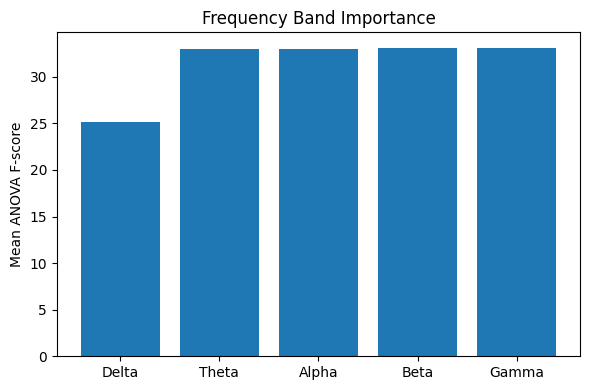

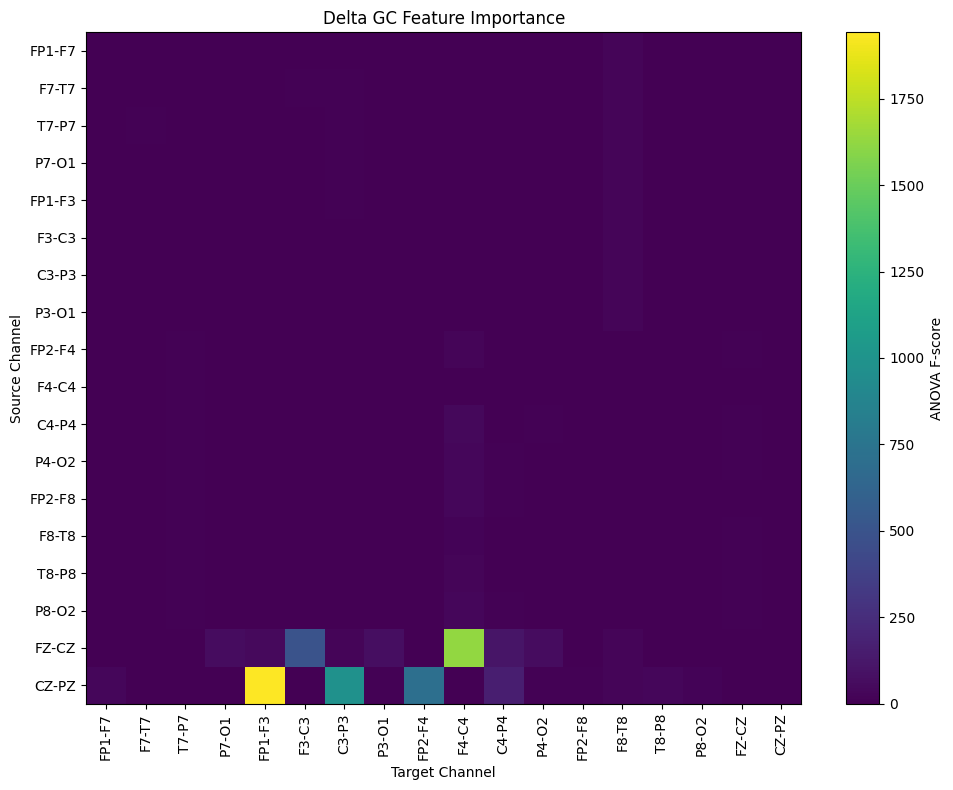

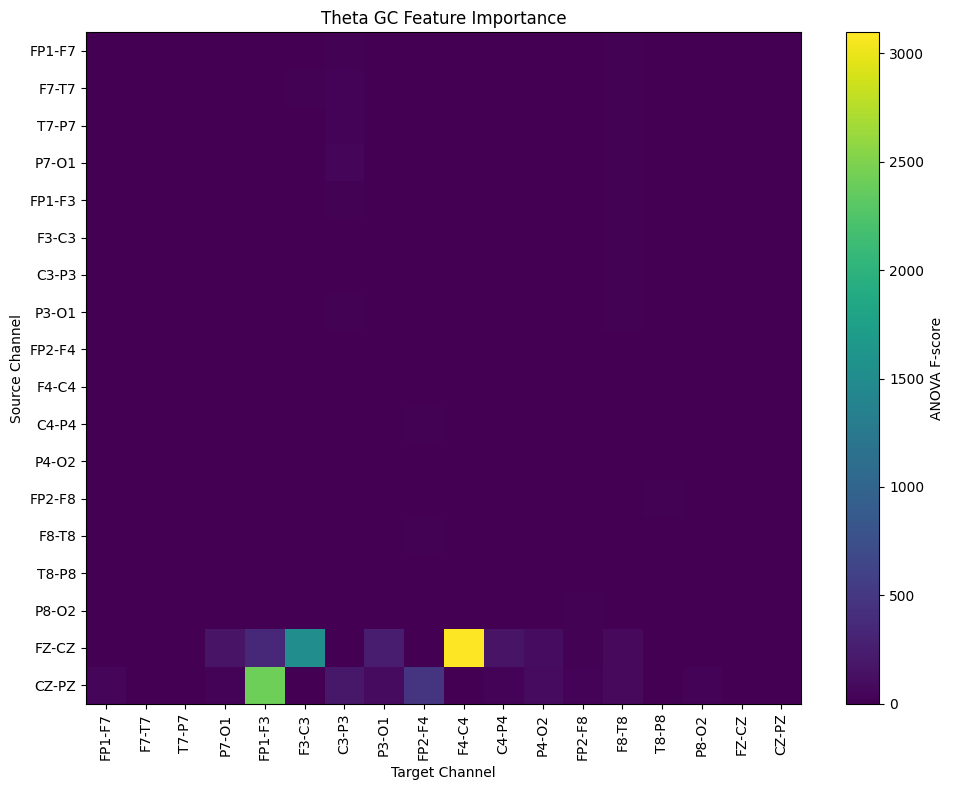

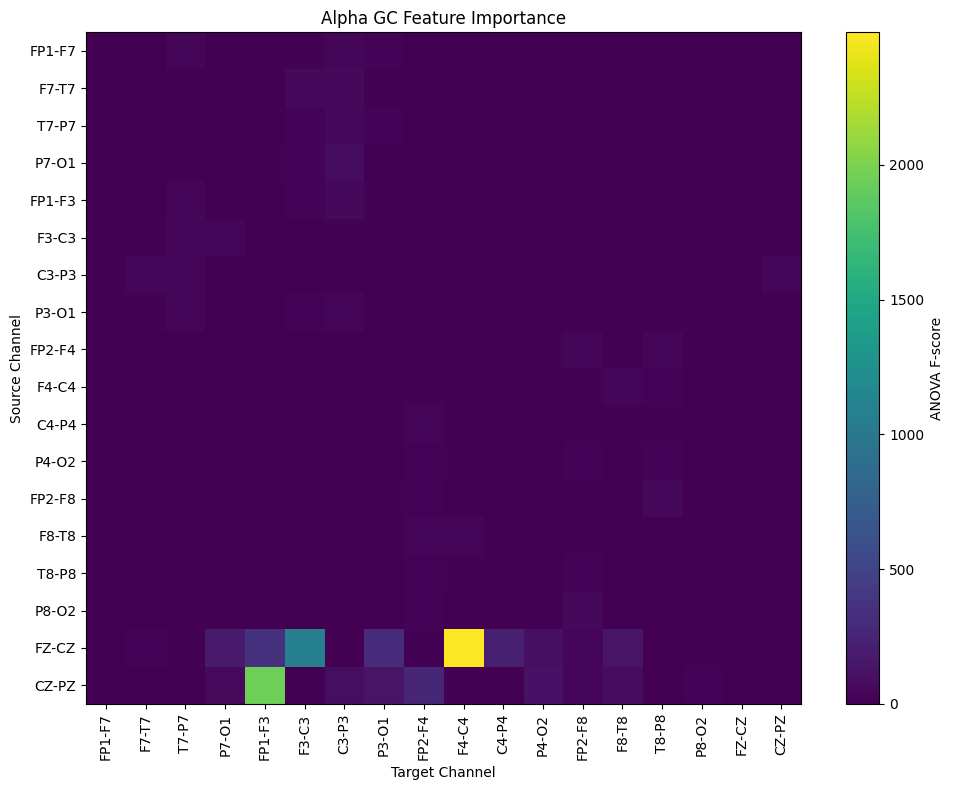

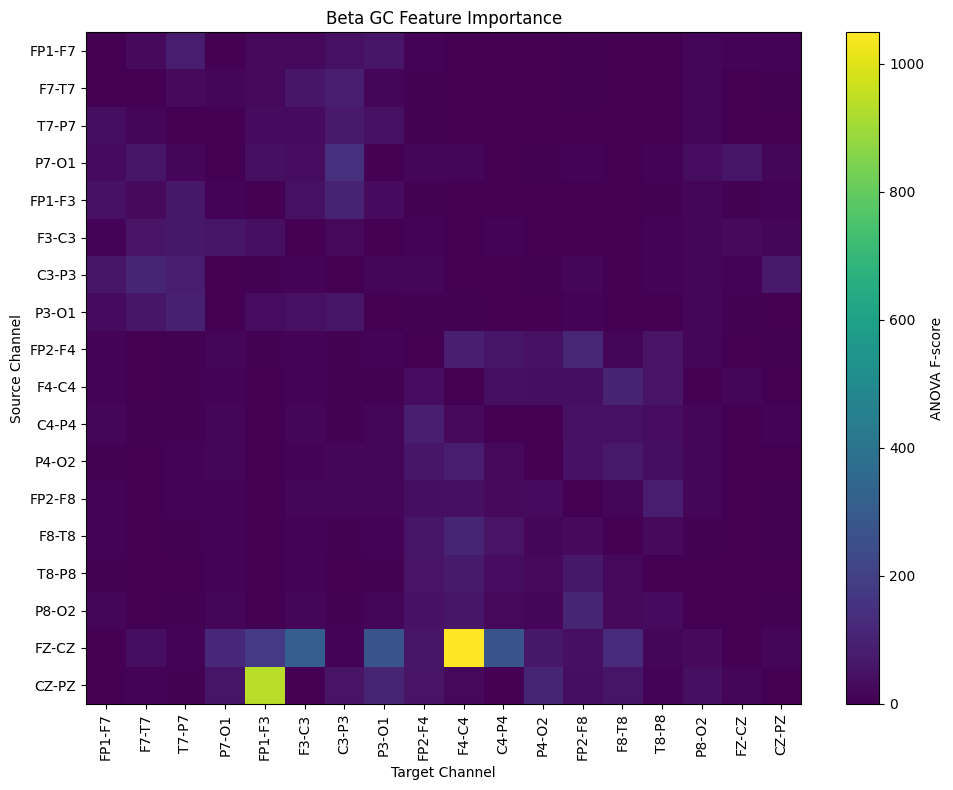

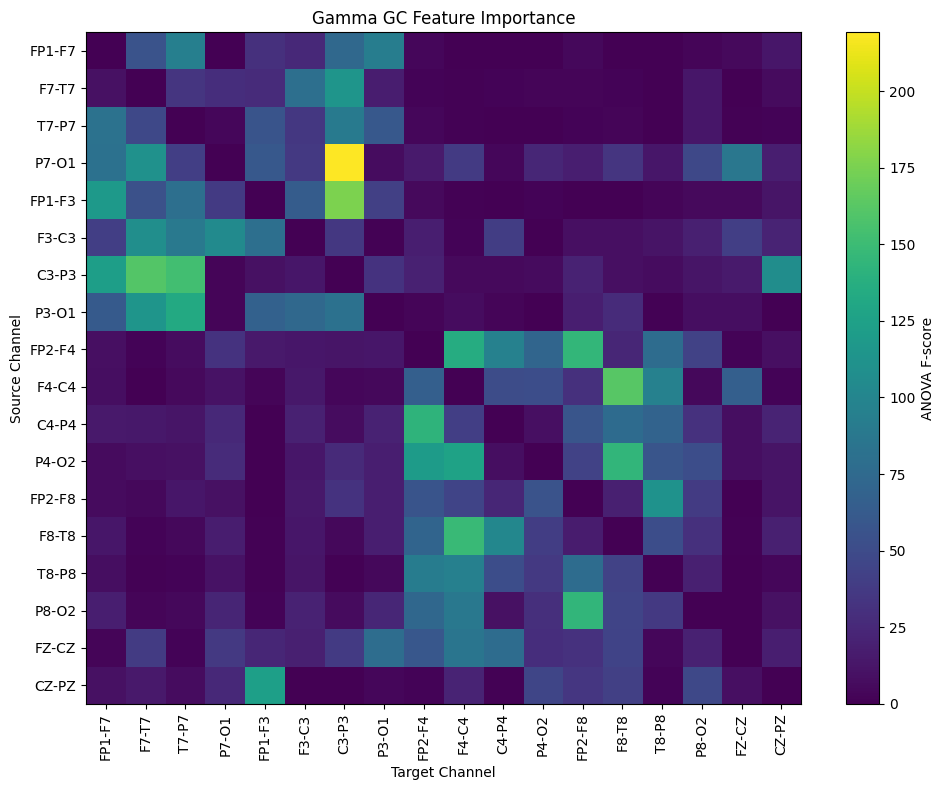


Top channels by outgoing GC importance:

FZ-CZ       16498.02
CZ-PZ       12186.50
P7-O1       1708.95
C3-P3       1416.32
FP2-F4      1414.09
P4-O2       1357.96
FP1-F3      1300.14
P3-O1       1274.19
F3-C3       1250.45
P8-O2       1228.15
C4-P4       1199.99
F4-C4       1172.79
F8-T8       1127.12
FP2-F8      1049.09
FP1-F7      1023.46
T8-P8       991.49
T7-P7       980.51
F7-T7       962.21


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_classif

# =====================================================
# COMBINE ALL RECORDS
# =====================================================

X_all = np.vstack([X for X, y in records.values()])
y_all = np.hstack([y for X, y in records.values()])

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

F, p = f_classif(X_all, y_all)

# =====================================================
# SETTINGS
# =====================================================

channels = [
    "FP1-F7","F7-T7","T7-P7","P7-O1",
    "FP1-F3","F3-C3","C3-P3","P3-O1",
    "FP2-F4","F4-C4","C4-P4","P4-O2",
    "FP2-F8","F8-T8","T8-P8","P8-O2",
    "FZ-CZ","CZ-PZ"
]

bands = [
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma"
]

n_channels = len(channels)
pairs_per_band = n_channels * (n_channels - 1)

print("Expected features:", len(bands) * pairs_per_band)
print("Actual features:", len(F))

# =====================================================
# BAND IMPORTANCE
# =====================================================

band_importance = []

for b in range(len(bands)):
    start = b * pairs_per_band
    end = start + pairs_per_band

    band_importance.append(F[start:end].mean())

plt.figure(figsize=(6,4))
plt.bar(bands, band_importance)
plt.ylabel("Mean ANOVA F-score")
plt.title("Frequency Band Importance")
plt.tight_layout()
plt.show()

# =====================================================
# GC HEATMAPS
# =====================================================

for b, band in enumerate(bands):

    start = b * pairs_per_band
    end = start + pairs_per_band

    band_scores = F[start:end]

    gc_matrix = np.zeros((n_channels, n_channels))

    idx = 0

    for src in range(n_channels):
        for dst in range(n_channels):

            if src == dst:
                continue

            gc_matrix[src, dst] = band_scores[idx]
            idx += 1

    plt.figure(figsize=(10,8))

    im = plt.imshow(gc_matrix, aspect='auto')

    plt.colorbar(im, label='ANOVA F-score')

    plt.xticks(
        np.arange(n_channels),
        channels,
        rotation=90
    )

    plt.yticks(
        np.arange(n_channels),
        channels
    )

    plt.xlabel("Target Channel")
    plt.ylabel("Source Channel")

    plt.title(f"{band} GC Feature Importance")

    plt.tight_layout()
    plt.show()

# =====================================================
# TOP CHANNELS (OUTGOING)
# =====================================================

overall_gc = np.zeros((n_channels, n_channels))

for b in range(len(bands)):

    start = b * pairs_per_band
    end = start + pairs_per_band

    idx = 0

    for src in range(n_channels):
        for dst in range(n_channels):

            if src == dst:
                continue

            overall_gc[src, dst] += F[start + idx]
            idx += 1

outgoing = overall_gc.sum(axis=1)

ranking = np.argsort(outgoing)[::-1]

print("\nTop channels by outgoing GC importance:\n")

for r in ranking:
    print(f"{channels[r]:10s}  {outgoing[r]:.2f}")

chb13_19_seizure (1437, 1530) (1437,)
chb13_21_seizure (1437, 1530) (1437,)
chb13_40_seizure (1437, 1530) (1437,)
chb13_55_seizure (1437, 1530) (1437,)
chb13_58_seizure (1437, 1530) (1437,)
chb13_59_seizure (1437, 1530) (1437,)
chb13_60_seizure (1437, 1530) (1437,)
chb13_62_seizure (1437, 1530) (1437,)


In [53]:
X_all = np.vstack([X for X, y in records.values()])
y_all = np.hstack([y for X, y in records.values()])

In [55]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

# ----------------------------------
# COMBINE ALL FILES
# ----------------------------------
X_all = np.vstack([X for X, y in records.values()])
y_all = np.hstack([y for X, y in records.values()])

print("Total windows:", X_all.shape)
print("Class counts:", np.bincount(y_all.astype(int)))

# ----------------------------------
# TRAIN / TEST SPLIT
# ----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.1,
    random_state=42,
    stratify=y_all
)

# ----------------------------------
# FEATURE SELECTION (TRAIN ONLY)
# ----------------------------------
selector = SelectKBest(f_classif, k=30)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# ----------------------------------
# SCALING (TRAIN ONLY)
# ----------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------------
# MODEL
# ----------------------------------
model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# ----------------------------------
# PREDICTIONS
# ----------------------------------
y_pred = model.predict(X_test)

# continuous scores for ROC-AUC/AUPRC
scores = model.decision_function(X_test)

# ----------------------------------
# METRICS
# ----------------------------------
acc = accuracy_score(y_test, y_pred)

auc = roc_auc_score(y_test, scores)
auprc = average_precision_score(y_test, scores)

sens = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

bac = balanced_accuracy_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
spec = tn / (tn + fp)

# ----------------------------------
# RESULTS
# ----------------------------------
print("\n===== RANDOM WINDOW SPLIT =====")
print(f"Accuracy      : {acc:.3f}")
print(f"ROC-AUC       : {auc:.3f}")
print(f"AUPRC         : {auprc:.3f}")
print(f"Sensitivity   : {sens:.3f}")
print(f"Specificity   : {spec:.3f}")
print(f"Precision     : {prec:.3f}")
print(f"F1            : {f1:.3f}")
print(f"Balanced Acc  : {bac:.3f}")

print("\nConfusion Matrix")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

# prevalence and baseline AUPRC
baseline_auprc = np.mean(y_test)
print(f"\nPositive prevalence : {baseline_auprc:.4f}")
print(f"Baseline AUPRC      : {baseline_auprc:.4f}")

Total windows: (13912, 1530)
Class counts: [13511   401]

===== RANDOM WINDOW SPLIT =====
Accuracy      : 0.983
ROC-AUC       : 0.920
AUPRC         : 0.699
Sensitivity   : 0.650
Specificity   : 0.993
Precision     : 0.722
F1            : 0.684
Balanced Acc  : 0.821

Confusion Matrix
TN = 1342
FP = 10
FN = 14
TP = 26

Positive prevalence : 0.0287
Baseline AUPRC      : 0.0287


In [172]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

# =====================================================
# COMBINE ALL FILES
# =====================================================

X_all = np.vstack([X for X, y in records.values()])
y_all = np.hstack([y for X, y in records.values()])

print("Total windows:", X_all.shape)
print("Class counts :", np.bincount(y_all.astype(int)))

# =====================================================
# 70 / 20 / 10 SPLIT
# =====================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.10,
    random_state=42,
    stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=20/90,
    random_state=42,
    stratify=y_temp
)

print("\nDataset sizes")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

# =====================================================
# HYPERPARAMETER GRID
# =====================================================

k_values = [25, 50, 75, 100, 150]

C_values = [0.01, 0.1, 1, 10]

gamma_values = [
    'scale',
    1e-4,
    1e-3,
    1e-2
]

best_auprc = -np.inf
best_params = None
best_model = None
best_selector = None
best_scaler = None

print("\n========================")
print("VALIDATION SEARCH")
print("========================")

for k in k_values:

    # -----------------------------
    # feature selection
    # -----------------------------
    selector = SelectKBest(f_classif, k=k)

    X_train_fs = selector.fit_transform(X_train, y_train)
    X_val_fs = selector.transform(X_val)

    # -----------------------------
    # scaling
    # -----------------------------
    scaler = StandardScaler()

    X_train_fs = scaler.fit_transform(X_train_fs)
    X_val_fs = scaler.transform(X_val_fs)

    # -----------------------------
    # SVM grid
    # -----------------------------
    for C in C_values:
        for gamma in gamma_values:

            model = SVC(
                kernel='rbf',
                C=C,
                gamma=gamma,
                class_weight='balanced'
            )

            model.fit(X_train_fs, y_train)

            val_scores = model.decision_function(X_val_fs)

            val_auc = roc_auc_score(y_val, val_scores)
            val_auprc = average_precision_score(y_val, val_scores)

            print(
                f"k={k:<3} "
                f"C={C:<5} "
                f"gamma={str(gamma):<8} "
                f"AUC={val_auc:.3f} "
                f"AUPRC={val_auprc:.3f}"
            )

            if val_auprc > best_auprc:
                best_auprc = val_auprc
                best_params = (k, C, gamma)

                best_model = model
                best_selector = selector
                best_scaler = scaler

# =====================================================
# BEST PARAMETERS
# =====================================================

best_k, best_C, best_gamma = best_params

print("\n========================")
print("BEST PARAMETERS")
print("========================")
print("k      =", best_k)
print("C      =", best_C)
print("gamma  =", best_gamma)
print("Val AUPRC =", round(best_auprc, 3))

# =====================================================
# TEST SET
# =====================================================

X_test_fs = best_selector.transform(X_test)
X_test_fs = best_scaler.transform(X_test_fs)

y_pred = best_model.predict(X_test_fs)
scores = best_model.decision_function(X_test_fs)

# =====================================================
# METRICS
# =====================================================

acc = accuracy_score(y_test, y_pred)

auc = roc_auc_score(y_test, scores)
auprc = average_precision_score(y_test, scores)

sens = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

bac = balanced_accuracy_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
spec = tn / (tn + fp)

# =====================================================
# RESULTS
# =====================================================

print("\n========================")
print("TEST RESULTS")
print("========================")

print(f"Accuracy      : {acc:.3f}")
print(f"ROC-AUC       : {auc:.3f}")
print(f"AUPRC         : {auprc:.3f}")
print(f"Sensitivity   : {sens:.3f}")
print(f"Specificity   : {spec:.3f}")
print(f"Precision     : {prec:.3f}")
print(f"F1            : {f1:.3f}")
print(f"Balanced Acc  : {bac:.3f}")

print("\nConfusion Matrix")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

baseline_auprc = np.mean(y_test)

print("\nPositive prevalence :", round(baseline_auprc, 4))
print("Baseline AUPRC      :", round(baseline_auprc, 4))

Total windows: (11496, 1530)
Class counts : [11280   216]

Dataset sizes
Train: (8046, 1530)
Val  : (2300, 1530)
Test : (1150, 1530)

VALIDATION SEARCH
k=25  C=0.01  gamma=scale    AUC=0.688 AUPRC=0.071
k=25  C=0.01  gamma=0.0001   AUC=0.611 AUPRC=0.026
k=25  C=0.01  gamma=0.001    AUC=0.616 AUPRC=0.026
k=25  C=0.01  gamma=0.01     AUC=0.662 AUPRC=0.037
k=25  C=0.1   gamma=scale    AUC=0.759 AUPRC=0.065
k=25  C=0.1   gamma=0.0001   AUC=0.617 AUPRC=0.026
k=25  C=0.1   gamma=0.001    AUC=0.686 AUPRC=0.038
k=25  C=0.1   gamma=0.01     AUC=0.735 AUPRC=0.096
k=25  C=1     gamma=scale    AUC=0.781 AUPRC=0.056
k=25  C=1     gamma=0.0001   AUC=0.696 AUPRC=0.037
k=25  C=1     gamma=0.001    AUC=0.742 AUPRC=0.067
k=25  C=1     gamma=0.01     AUC=0.781 AUPRC=0.073
k=25  C=10    gamma=scale    AUC=0.747 AUPRC=0.053
k=25  C=10    gamma=0.0001   AUC=0.742 AUPRC=0.065
k=25  C=10    gamma=0.001    AUC=0.764 AUPRC=0.075
k=25  C=10    gamma=0.01     AUC=0.822 AUPRC=0.068
k=50  C=0.01  gamma=scale    AUC

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [163]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

results = []

for test_record in records:

    # -----------------------------
    # SPLIT (LORO)
    # -----------------------------
    X_test, y_test = records[test_record]

    X_train = np.vstack([records[r][0] for r in records if r != test_record])
    y_train = np.concatenate([records[r][1] for r in records if r != test_record])

    # -----------------------------
    # 1. FEATURE SELECTION (TRAIN ONLY)
    # -----------------------------
    selector = SelectKBest(f_classif, k=50)
    X_train = selector.fit_transform(X_train, y_train)
    X_test = selector.transform(X_test)

    # -----------------------------
    # 2. SCALING (TRAIN ONLY)
    # -----------------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -----------------------------
    # 3. MODEL
    # -----------------------------
    model = SVC(
        kernel='rbf',
        C=100,
        gamma='scale',
        class_weight='balanced'
    )

    model.fit(X_train, y_train)

    # -----------------------------
    # 4. PREDICTION
    # -----------------------------
    y_pred = model.predict(X_test)
    scores = model.decision_function(X_test)

    # -----------------------------
    # 5. METRICS
    # -----------------------------
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores)

    sens = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    bac = balanced_accuracy_score(y_test, y_pred)

    # -----------------------------
    # 6. SPECIFICITY (NEW)
    # -----------------------------
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    print(f"\n===== {test_record} =====")
    print("Accuracy:", acc)
    print("AUC:", auc)
    print("Sensitivity:", sens)
    print("Specificity:", spec)
    print("Precision:", prec)
    print("F1:", f1)
    print("Balanced Acc:", bac)

    results.append([acc, auc, sens, spec, prec, f1, bac])


===== chb01_03 =====
Accuracy: 0.988169798190675
AUC: 0.9573363828289936
Sensitivity: 0.3125
Specificity: 0.995777621393385
Precision: 0.45454545454545453
F1: 0.37037037037037035
Balanced Acc: 0.6541388106966926

===== chb01_04 =====
Accuracy: 0.9944328462073765
AUC: 0.9951549152110162
Sensitivity: 0.6363636363636364
Specificity: 0.9971949509116409
Precision: 0.6363636363636364
F1: 0.6363636363636364
Balanced Acc: 0.8167792936376386

===== chb01_15 =====
Accuracy: 0.9756437021572721
AUC: 0.6888194933145673
Sensitivity: 0.125
Specificity: 0.9852216748768473
Precision: 0.08695652173913043
F1: 0.10256410256410256
Balanced Acc: 0.5551108374384237

===== chb01_16 =====
Accuracy: 0.9874739039665971
AUC: 0.9947202044659672
Sensitivity: 0.2857142857142857
Specificity: 0.9978813559322034
Precision: 0.6666666666666666
F1: 0.4
Balanced Acc: 0.6417978208232445

===== chb01_18 =====
Accuracy: 0.9819067501739736
AUC: 0.9939189189189189
Sensitivity: 0.43243243243243246
Specificity: 0.996428571428571

In [114]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix
)
import numpy as np

results = []

for test_record in records:
    # -----------------------------
    # SPLIT (LORO)
    # -----------------------------
    X_test, y_test = records[test_record]
    X_train = np.vstack([records[r][0] for r in records if r != test_record])
    y_train = np.concatenate([records[r][1] for r in records if r != test_record])

    # -----------------------------
    # 1. FEATURE SELECTION (TRAIN ONLY)
    # -----------------------------
    selector = SelectKBest(f_classif, k=50)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)

    # -----------------------------
    # 2. SCALING (TRAIN ONLY)
    # -----------------------------
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_sel)
    X_test_sc = scaler.transform(X_test_sel)

    # -----------------------------
    # 3. MODEL
    # -----------------------------
    model = SVC(
        kernel='rbf',
        C=0.1,
        gamma= 'scale',
        class_weight='balanced'
    )
    model.fit(X_train_sc, y_train)

    # -----------------------------
    # 4. PREDICTION
    # -----------------------------
    y_pred = model.predict(X_test_sc)
    scores = model.decision_function(X_test_sc)

    # -----------------------------
    # 5. METRICS
    # -----------------------------
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores)
    auprc = average_precision_score(y_test, scores)  # key metric under imbalance
    sens = recall_score(y_test, y_pred, zero_division=0)
    bac = balanced_accuracy_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f"\n===== {test_record} =====")
    print(f"  Accuracy:         {acc:.3f} ")
    print(f"  ROC-AUC:          {auc:.3f}")
    print(f"  AUPRC:            {auprc:.3f}")
    print(f"  Sensitivity:      {sens:.3f}  (segment-level)")
    print(f"  Specificity:      {spec:.3f}")
    print(f"  Balanced Acc:     {bac:.3f}")

    results.append({
        'record': test_record,
        'accuracy': acc,
        'roc_auc': auc,
        'auprc': auprc,
        'sensitivity': sens,
        'specificity': spec,
        'balanced_acc': bac,
        'scores': scores,        # keep for event-level scoring
        'y_test': y_test,        # keep for event-level scoring
        'y_pred': y_pred
    })


===== chb13_19 =====
  Accuracy:         0.880 
  ROC-AUC:          0.600
  AUPRC:            0.019
  Sensitivity:      0.111  (segment-level)
  Specificity:      0.890
  Balanced Acc:     0.501

===== chb13_21 =====
  Accuracy:         0.903 
  ROC-AUC:          0.767
  AUPRC:            0.069
  Sensitivity:      0.357  (segment-level)
  Specificity:      0.913
  Balanced Acc:     0.635

===== chb13_40 =====
  Accuracy:         0.916 
  ROC-AUC:          0.474
  AUPRC:            0.025
  Sensitivity:      0.026  (segment-level)
  Specificity:      0.941
  Balanced Acc:     0.483

===== chb13_55 =====
  Accuracy:         0.900 
  ROC-AUC:          0.581
  AUPRC:            0.023
  Sensitivity:      0.133  (segment-level)
  Specificity:      0.908
  Balanced Acc:     0.521

===== chb13_58 =====
  Accuracy:         0.878 
  ROC-AUC:          0.476
  AUPRC:            0.005
  Sensitivity:      0.000  (segment-level)
  Specificity:      0.882
  Balanced Acc:     0.441

===== chb13_59 ====

In [165]:
from dataclasses import dataclass
import numpy as np

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix
)

# =====================================================
# PARAMETERS
# =====================================================

WIN_SEC = 10.0
STEP_SEC = 2.5      # 75% overlap
K_FEATURES = 50

# =====================================================
# EVENT-LEVEL UTILITIES
# =====================================================

@dataclass
class RecordPrediction:
    record_id: str
    window_starts: np.ndarray
    window_len: float
    scores: np.ndarray
    duration_sec: float
    seizures: list


def labels_to_seizures(y, step_sec=2.5, win_sec=10.0):

    seizures = []

    ictal = (y == 1)

    i = 0
    while i < len(ictal):

        if ictal[i]:

            j = i
            while j + 1 < len(ictal) and ictal[j + 1]:
                j += 1

            onset = i * step_sec
            offset = j * step_sec + win_sec

            seizures.append((onset, offset))

            i = j + 1

        else:
            i += 1

    return seizures


def _runs_of_true(mask):

    runs = []
    i = 0

    while i < len(mask):

        if mask[i]:

            j = i

            while j + 1 < len(mask) and mask[j + 1]:
                j += 1

            runs.append((i, j))
            i = j + 1

        else:
            i += 1

    return runs


def detect_events(rec,
                  threshold=0.0,
                  k_consecutive=2,
                  refractory_sec=120):

    pred = rec.scores >= threshold

    events = []

    for s, e in _runs_of_true(pred):

        if (e - s + 1) >= k_consecutive:

            onset = rec.window_starts[s]
            offset = rec.window_starts[e] + rec.window_len

            events.append({
                "onset_sec": onset,
                "offset_sec": offset
            })

    accepted = []
    last_time = -np.inf

    for ev in events:

        if ev["onset_sec"] >= last_time + refractory_sec:

            accepted.append(ev)
            last_time = ev["onset_sec"]

    return accepted


def score_records(event_records,
                  threshold=0.0,
                  k_consecutive=2,
                  refractory_sec=120):

    total_seizures = 0
    detected_seizures = 0
    false_detections = 0
    total_hours = 0

    latencies = []

    for rec in event_records:

        total_hours += rec.duration_sec / 3600

        events = detect_events(
            rec,
            threshold,
            k_consecutive,
            refractory_sec
        )

        matched_event = [False] * len(events)

        for onset, offset in rec.seizures:

            total_seizures += 1

            seizure_detected = False

            for idx, ev in enumerate(events):

                overlap = (
                    ev["onset_sec"] <= offset and
                    ev["offset_sec"] >= onset
                )

                if overlap:

                    matched_event[idx] = True
                    seizure_detected = True

                    latencies.append(
                        ev["onset_sec"] - onset
                    )

            if seizure_detected:
                detected_seizures += 1

        false_detections += sum(
            1 for m in matched_event if not m
        )

    return {
        "sensitivity":
            detected_seizures / total_seizures
            if total_seizures else np.nan,

        "fd_per_hour":
            false_detections / total_hours
            if total_hours else np.nan,

        "median_latency_sec":
            np.median(latencies)
            if len(latencies) else np.nan,

        "n_seizures":
            total_seizures,

        "n_detected":
            detected_seizures,

        "n_false_detections":
            false_detections
    }

# =====================================================
# LORO TRAINING
# =====================================================

results = []
event_records = []

for test_record in records:

    print(f"\nTesting: {test_record}")

    # -------------------------------------------------
    # SPLIT
    # -------------------------------------------------

    X_test, y_test = records[test_record]

    X_train = np.vstack([
        records[r][0]
        for r in records
        if r != test_record
    ])

    y_train = np.concatenate([
        records[r][1]
        for r in records
        if r != test_record
    ])

    # -------------------------------------------------
    # FEATURE SELECTION
    # -------------------------------------------------

    selector = SelectKBest(
        score_func=f_classif,
        k=K_FEATURES
    )

    X_train = selector.fit_transform(
        X_train,
        y_train
    )

    X_test = selector.transform(
        X_test
    )

    # -------------------------------------------------
    # SCALING
    # -------------------------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    # -------------------------------------------------
    # SVM
    # -------------------------------------------------

    model = SVC(
        kernel='rbf',
        C=0.1,
        gamma='scale',
        class_weight='balanced'
    )

    model.fit(X_train, y_train)

    # -------------------------------------------------
    # PREDICTIONS
    # -------------------------------------------------

    y_pred = model.predict(X_test)

    scores = model.decision_function(X_test)

    # -------------------------------------------------
    # SEGMENT-LEVEL METRICS
    # -------------------------------------------------

    acc = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, scores)

    auprc = average_precision_score(
        y_test,
        scores
    )

    sens = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    bac = balanced_accuracy_score(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    spec = tn / (tn + fp)

    print(f"Accuracy      : {acc:.3f}")
    print(f"ROC-AUC       : {auc:.3f}")
    print(f"AUPRC         : {auprc:.3f}")
    print(f"Sensitivity   : {sens:.3f}")
    print(f"Specificity   : {spec:.3f}")
    print(f"Balanced Acc  : {bac:.3f}")

    results.append({
        "record": test_record,
        "accuracy": acc,
        "roc_auc": auc,
        "auprc": auprc,
        "sensitivity": sens,
        "specificity": spec,
        "balanced_acc": bac
    })

    # -------------------------------------------------
    # EVENT-LEVEL OBJECT
    # -------------------------------------------------

    window_starts = (
        np.arange(len(y_test))
        * STEP_SEC
    )

    duration_sec = (
        window_starts[-1]
        + WIN_SEC
    )

    seizures = labels_to_seizures(
        y_test,
        STEP_SEC,
        WIN_SEC
    )

    event_records.append(
        RecordPrediction(
            record_id=test_record,
            window_starts=window_starts,
            window_len=WIN_SEC,
            scores=scores,
            duration_sec=duration_sec,
            seizures=seizures
        )
    )

# =====================================================
# OVERALL SEGMENT RESULTS
# =====================================================

print("\n========================")
print("SEGMENT-LEVEL RESULTS")
print("========================")

print(
    "Mean ROC-AUC:",
    np.mean([r["roc_auc"] for r in results])
)

print(
    "Mean AUPRC:",
    np.mean([r["auprc"] for r in results])
)

print(
    "Mean Sensitivity:",
    np.mean([r["sensitivity"] for r in results])
)

print(
    "Mean Specificity:",
    np.mean([r["specificity"] for r in results])
)

# =====================================================
# EVENT-LEVEL RESULTS
# =====================================================
for th in [0.0, 0.5, 1.0, 2.0]:
    for k in [2, 4, 6, 8]:
        out = score_records(
            event_records,
            threshold=th,
            k_consecutive=k,
            refractory_sec=120
        )
        print(
            f"th={th:3.1f}, k={k:2d} | "
            f"sens={out['sensitivity']:.3f}, "
            f"FD/h={out['fd_per_hour']:.3f}, "
            f"latency={out['median_latency_sec']:.1f}s"
        )
    print()


Testing: chb01_03
Accuracy      : 0.981
ROC-AUC       : 0.992
AUPRC         : 0.541
Sensitivity   : 0.938
Specificity   : 0.981
Balanced Acc  : 0.959

Testing: chb01_04
Accuracy      : 0.958
ROC-AUC       : 0.987
AUPRC         : 0.291
Sensitivity   : 1.000
Specificity   : 0.958
Balanced Acc  : 0.979

Testing: chb01_15
Accuracy      : 0.944
ROC-AUC       : 0.802
AUPRC         : 0.033
Sensitivity   : 0.125
Specificity   : 0.953
Balanced Acc  : 0.539

Testing: chb01_16
Accuracy      : 0.980
ROC-AUC       : 0.994
AUPRC         : 0.614
Sensitivity   : 1.000
Specificity   : 0.980
Balanced Acc  : 0.990

Testing: chb01_18
Accuracy      : 0.983
ROC-AUC       : 0.996
AUPRC         : 0.855
Sensitivity   : 1.000
Specificity   : 0.982
Balanced Acc  : 0.991

Testing: chb01_21
Accuracy      : 0.997
ROC-AUC       : 0.993
AUPRC         : 0.970
Sensitivity   : 0.947
Specificity   : 0.998
Balanced Acc  : 0.973

Testing: chb01_26
Accuracy      : 0.988
ROC-AUC       : 0.980
AUPRC         : 0.937
Sensitivi

In [159]:
print(
    f"th={th:3.1f}, "
    f"k={k}, "
    f"sens={out['sensitivity']:.3f}, "
    f"FD/h={out['fd_per_hour']:.3f}, "
    f"latency={out.get('mean_latency_sec', float('nan')):.1f}s"
)

th=0.5, k=6, sens=1.000, FD/h=0.150, latency=nans


# With leakage

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix
)

import numpy as np

# =====================================================
# PARAMETERS
# =====================================================

K_FEATURES = 50

# =====================================================
# COMBINE ALL RECORDS
# =====================================================

X_all = np.vstack([
    records[r][0]
    for r in records
])

y_all = np.concatenate([
    records[r][1]
    for r in records
])

print("Total windows :", X_all.shape[0])
print("N features    :", X_all.shape[1])

unique, counts = np.unique(y_all, return_counts=True)
print("Class counts  :", dict(zip(unique, counts)))

# =====================================================
# RANDOM TRAIN / TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)

# =====================================================
# FEATURE SELECTION (TRAIN ONLY)
# =====================================================

selector = SelectKBest(
    score_func=f_classif,
    k=K_FEATURES
)

X_train = selector.fit_transform(
    X_train,
    y_train
)

X_test = selector.transform(
    X_test
)

# =====================================================
# SCALING (TRAIN ONLY)
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# =====================================================
# SVM
# =====================================================

model = SVC(
    kernel='rbf',
    C=0.1,
    gamma='scale',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

scores = model.decision_function(X_test)

# =====================================================
# METRICS
# =====================================================

acc = accuracy_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    scores
)

auprc = average_precision_score(
    y_test,
    scores
)

sens = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

bac = balanced_accuracy_score(
    y_test,
    y_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
).ravel()

spec = tn / (tn + fp)

# =====================================================
# RESULTS
# =====================================================

print("\n========================")
print("RANDOM WINDOW SPLIT")
print("========================")

print(f"Accuracy      : {acc:.3f}")
print(f"ROC-AUC       : {auc:.3f}")
print(f"AUPRC         : {auprc:.3f}")
print(f"Sensitivity   : {sens:.3f}")
print(f"Specificity   : {spec:.3f}")
print(f"Balanced Acc  : {bac:.3f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Total windows : 9549
N features    : 1530
Class counts  : {0: 9369, 1: 180}

Train: (7639, 1530)
Test : (1910, 1530)

RANDOM WINDOW SPLIT
Accuracy      : 0.973
ROC-AUC       : 0.993
AUPRC         : 0.737
Sensitivity   : 0.972
Specificity   : 0.973
Balanced Acc  : 0.973

Confusion Matrix
[[1824   50]
 [   1   35]]


In [59]:
from dataclasses import dataclass
import numpy as np

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix
)

# =====================================================
# PARAMETERS
# =====================================================

WIN_SEC = 10.0
STEP_SEC = 2.5      # 75% overlap
K_FEATURES = 50

# =====================================================
# EVENT-LEVEL UTILITIES
# =====================================================

@dataclass
class RecordPrediction:
    record_id: str
    window_starts: np.ndarray
    window_len: float
    scores: np.ndarray
    duration_sec: float
    seizures: list


def labels_to_seizures(y, step_sec=2.5, win_sec=10.0):

    seizures = []

    ictal = (y == 1)

    i = 0
    while i < len(ictal):

        if ictal[i]:

            j = i
            while j + 1 < len(ictal) and ictal[j + 1]:
                j += 1

            onset = i * step_sec
            offset = j * step_sec + win_sec

            seizures.append((onset, offset))

            i = j + 1

        else:
            i += 1

    return seizures


def _runs_of_true(mask):

    runs = []
    i = 0

    while i < len(mask):

        if mask[i]:

            j = i

            while j + 1 < len(mask) and mask[j + 1]:
                j += 1

            runs.append((i, j))
            i = j + 1

        else:
            i += 1

    return runs


def detect_events(rec,
                  threshold=0.0,
                  k_consecutive=2,
                  refractory_sec=120):

    pred = rec.scores >= threshold

    events = []

    for s, e in _runs_of_true(pred):

        if (e - s + 1) >= k_consecutive:

            onset = rec.window_starts[s]
            offset = rec.window_starts[e] + rec.window_len

            events.append({
                "onset_sec": onset,
                "offset_sec": offset
            })

    accepted = []
    last_time = -np.inf

    for ev in events:

        if ev["onset_sec"] >= last_time + refractory_sec:

            accepted.append(ev)
            last_time = ev["onset_sec"]

    return accepted


def score_records(event_records,
                  threshold=0.0,
                  k_consecutive=2,
                  refractory_sec=120):

    total_seizures = 0
    detected_seizures = 0
    false_detections = 0
    total_hours = 0

    latencies = []

    for rec in event_records:

        total_hours += rec.duration_sec / 3600

        events = detect_events(
            rec,
            threshold,
            k_consecutive,
            refractory_sec
        )

        matched_event = [False] * len(events)

        for onset, offset in rec.seizures:

            total_seizures += 1

            seizure_detected = False

            for idx, ev in enumerate(events):

                overlap = (
                    ev["onset_sec"] <= offset and
                    ev["offset_sec"] >= onset
                )

                if overlap:

                    matched_event[idx] = True
                    seizure_detected = True

                    latencies.append(
                        ev["onset_sec"] - onset
                    )

            if seizure_detected:
                detected_seizures += 1

        false_detections += sum(
            1 for m in matched_event if not m
        )

    return {
        "sensitivity":
            detected_seizures / total_seizures
            if total_seizures else np.nan,

        "fd_per_hour":
            false_detections / total_hours
            if total_hours else np.nan,

        "median_latency_sec":
            np.median(latencies)
            if len(latencies) else np.nan,

        "n_seizures":
            total_seizures,

        "n_detected":
            detected_seizures,

        "n_false_detections":
            false_detections
    }

# =====================================================
# LORO TRAINING
# =====================================================

results = []
event_records = []

for test_record in records:

    print(f"\nTesting: {test_record}")

    # -------------------------------------------------
    # SPLIT
    # -------------------------------------------------

    X_test, y_test = records[test_record]

    X_train = np.vstack([
        records[r][0]
        for r in records
        if r != test_record
    ])

    y_train = np.concatenate([
        records[r][1]
        for r in records
        if r != test_record
    ])

    # -------------------------------------------------
    # FEATURE SELECTION
    # -------------------------------------------------

    selector = SelectKBest(
        score_func=f_classif,
        k=K_FEATURES
    )

    X_train = selector.fit_transform(
        X_train,
        y_train
    )

    X_test = selector.transform(
        X_test
    )

    # -------------------------------------------------
    # SCALING
    # -------------------------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    # -------------------------------------------------
    # SVM
    # -------------------------------------------------

    model = SVC(
        kernel='rbf',
        C=0.1,
        gamma='scale',
        class_weight={0: 1, 1: 100} 
    )

    model.fit(X_train, y_train)

    # -------------------------------------------------
    # PREDICTIONS
    # -------------------------------------------------

    y_pred = model.predict(X_test)

    scores = model.decision_function(X_test)

    # -------------------------------------------------
    # SEGMENT-LEVEL METRICS
    # -------------------------------------------------

    acc = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, scores)

    auprc = average_precision_score(
        y_test,
        scores
    )

    sens = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    bac = balanced_accuracy_score(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    spec = tn / (tn + fp)

    print(f"Accuracy      : {acc:.3f}")
    print(f"ROC-AUC       : {auc:.3f}")
    print(f"AUPRC         : {auprc:.3f}")
    print(f"Sensitivity   : {sens:.3f}")
    print(f"Specificity   : {spec:.3f}")
    print(f"Balanced Acc  : {bac:.3f}")

    results.append({
        "record": test_record,
        "accuracy": acc,
        "roc_auc": auc,
        "auprc": auprc,
        "sensitivity": sens,
        "specificity": spec,
        "balanced_acc": bac
    })

    # -------------------------------------------------
    # EVENT-LEVEL OBJECT
    # -------------------------------------------------

    window_starts = (
        np.arange(len(y_test))
        * STEP_SEC
    )

    duration_sec = (
        window_starts[-1]
        + WIN_SEC
    )

    seizures = labels_to_seizures(
        y_test,
        STEP_SEC,
        WIN_SEC
    )

    event_records.append(
        RecordPrediction(
            record_id=test_record,
            window_starts=window_starts,
            window_len=WIN_SEC,
            scores=scores,
            duration_sec=duration_sec,
            seizures=seizures
        )
    )

# =====================================================
# OVERALL SEGMENT RESULTS
# =====================================================

print("\n========================")
print("SEGMENT-LEVEL RESULTS")
print("========================")
print(
    "Mean Accuracy:",
    np.mean([r["accuracy"] for r in results])
)


print(
    "Mean ROC-AUC:",
    np.mean([r["roc_auc"] for r in results])
)

print(
    "Mean AUPRC:",
    np.mean([r["auprc"] for r in results])
)

print(
    "Mean Sensitivity:",
    np.mean([r["sensitivity"] for r in results])
)

print(
    "Mean Specificity:",
    np.mean([r["specificity"] for r in results])
)

# =====================================================
# EVENT-LEVEL RESULTS
# =====================================================
for th in [0.0, 0.5, 1.0, 2.0]:
    for k in [2, 4, 6, 8]:

        out = score_records(
            event_records,
            threshold=th,
            k_consecutive=k,
            refractory_sec=120
        )

        print(
            f"th={th:3.1f}, "
            f"k={k}, "
            f"sens={out['sensitivity']:.3f}, "
            f"FD/h={out['fd_per_hour']:.3f}"
        )


Testing: chb01_03
Accuracy      : 0.985
ROC-AUC       : 0.992
AUPRC         : 0.565
Sensitivity   : 0.938
Specificity   : 0.986
Balanced Acc  : 0.962

Testing: chb01_04
Accuracy      : 0.971
ROC-AUC       : 0.989
AUPRC         : 0.326
Sensitivity   : 1.000
Specificity   : 0.971
Balanced Acc  : 0.985

Testing: chb01_15
Accuracy      : 0.951
ROC-AUC       : 0.806
AUPRC         : 0.035
Sensitivity   : 0.125
Specificity   : 0.961
Balanced Acc  : 0.543

Testing: chb01_16
Accuracy      : 0.985
ROC-AUC       : 0.995
AUPRC         : 0.645
Sensitivity   : 1.000
Specificity   : 0.985
Balanced Acc  : 0.993

Testing: chb01_18
Accuracy      : 0.988
ROC-AUC       : 0.996
AUPRC         : 0.832
Sensitivity   : 1.000
Specificity   : 0.988
Balanced Acc  : 0.994

Testing: chb01_21
Accuracy      : 0.997
ROC-AUC       : 0.993
AUPRC         : 0.966
Sensitivity   : 0.921
Specificity   : 0.999
Balanced Acc  : 0.960

Testing: chb01_26
Accuracy      : 0.984
ROC-AUC       : 0.979
AUPRC         : 0.934
Sensitivi

# Random Forest

In [45]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

results = []

for test_record in records:

    # -----------------------------
    # SPLIT (LORO)
    # -----------------------------
    X_test, y_test = records[test_record]

    X_train = np.vstack([records[r][0] for r in records if r != test_record])
    y_train = np.concatenate([records[r][1] for r in records if r != test_record])

    # -----------------------------
    # FEATURE SELECTION
    # -----------------------------
    selector = SelectKBest(f_classif, k=50)
    X_train = selector.fit_transform(X_train, y_train)
    X_test = selector.transform(X_test)

    # -----------------------------
    # MODEL
    # -----------------------------
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # -----------------------------
    # PREDICTION
    # -----------------------------
    #y_pred = model.predict(X_test)
    scores = model.predict_proba(X_test)[:, 1]

    threshold = 0.1  # try 0.1–0.4

    y_pred = (scores >= threshold).astype(int)
    scores = model.predict_proba(X_test)[:, 1]   # ✅ FIX

    # -----------------------------
    # METRICS
    # -----------------------------
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores)

    sens = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    bac = balanced_accuracy_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    print(f"\n===== {test_record} =====")
    print("Accuracy:", acc)
    print("AUC:", auc)
    print("Sensitivity:", sens)
    print("Specificity:", spec)
    print("Precision:", prec)
    print("F1:", f1)

    results.append([acc, auc, sens, spec, prec, f1, bac])


===== chb01_03 =====
Accuracy: 0.9819067501739736
AUC: 0.9743578465869106
Sensitivity: 0.5
Specificity: 0.9873328641801549
Precision: 0.3076923076923077
F1: 0.38095238095238093

===== chb01_04 =====
Accuracy: 0.9617258176757133
AUC: 0.985400994517404
Sensitivity: 0.8181818181818182
Specificity: 0.9628330995792427
Precision: 0.14516129032258066
F1: 0.2465753424657534

===== chb01_15 =====
Accuracy: 0.954070981210856
AUC: 0.7071164672765657
Sensitivity: 0.125
Specificity: 0.9634060520760028
Precision: 0.037037037037037035
F1: 0.05714285714285714

===== chb01_16 =====
Accuracy: 0.9819067501739736
AUC: 0.9952246435297283
Sensitivity: 1.0
Specificity: 0.981638418079096
Precision: 0.44680851063829785
F1: 0.6176470588235294

===== chb01_18 =====
Accuracy: 0.9902574808629089
AUC: 0.9979536679536679
Sensitivity: 0.918918918918919
Specificity: 0.9921428571428571
Precision: 0.7555555555555555
F1: 0.8292682926829268

===== chb01_21 =====
Accuracy: 0.9944328462073765
AUC: 0.9992663932884391
Sensit

# Xgboost

In [55]:
import numpy as np

from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

results = []

# =====================================================
# LORO LOOP
# =====================================================

for test_record in records:

    print(f"\n===== {test_record} =====")

    # -----------------------------
    # SPLIT (LORO)
    # -----------------------------
    X_test, y_test = records[test_record]

    X_train = np.vstack([
        records[r][0]
        for r in records if r != test_record
    ])

    y_train = np.concatenate([
        records[r][1]
        for r in records if r != test_record
    ])

    # -----------------------------
    # FEATURE SELECTION
    # -----------------------------
    selector = SelectKBest(f_classif, k=50)

    X_train = selector.fit_transform(X_train, y_train)
    X_test = selector.transform(X_test)

    # -----------------------------
    # MODEL (XGBOOST)
    # -----------------------------
    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train == 0]) / max(len(y_train[y_train == 1]), 1),
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # -----------------------------
    # PREDICTION
    # -----------------------------
    scores = model.predict_proba(X_test)[:, 1]

    # threshold (YOU MUST TUNE THIS)
    threshold = 0.5
    y_pred = (scores >= threshold).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores)

    sens = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    bac = balanced_accuracy_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    # -----------------------------
    # PRINT RESULTS
    # -----------------------------
    print("Accuracy     :", acc)
    print("AUC          :", auc)
    print("Sensitivity  :", sens)
    print("Specificity  :", spec)
    print("Precision    :", prec)
    print("F1           :", f1)
    print("Balanced Acc :", bac)

    # -----------------------------
    # STORE
    # -----------------------------
    results.append([acc, auc, sens, spec, prec, f1, bac])


===== chb01_03 =====
Accuracy     : 0.9853862212943633
AUC          : 0.9717188599577763
Sensitivity  : 0.375
Specificity  : 0.9922589725545391
Precision    : 0.35294117647058826
F1           : 0.36363636363636365
Balanced Acc : 0.6836294862772696

===== chb01_04 =====
Accuracy     : 0.9867780097425192
AUC          : 0.9972587020272855
Sensitivity  : 1.0
Specificity  : 0.9866760168302945
Precision    : 0.36666666666666664
F1           : 0.5365853658536586
Balanced Acc : 0.9933380084151473

===== chb01_15 =====
Accuracy     : 0.9707724425887265
AUC          : 0.8637403237156932
Sensitivity  : 0.125
Specificity  : 0.9802955665024631
Precision    : 0.06666666666666667
F1           : 0.08695652173913043
Balanced Acc : 0.5526477832512315

===== chb01_16 =====
Accuracy     : 0.9951287404314544
AUC          : 0.995291902071563
Sensitivity  : 0.9523809523809523
Specificity  : 0.9957627118644068
Precision    : 0.7692307692307693
F1           : 0.851063829787234
Balanced Acc : 0.974071832122679